# Aerofit Treadmill — Descriptive Statistics & Probability Analysis
**Author:** Shital V Rewanwar

**Objective:** Build customer profiles for each treadmill model using descriptive analytics and probability to help the AeroFit sales team make better product recommendations.

---

## 1. Problem Statement

AeroFit sells three treadmill models:

<table>
  <tr>
    <th>Model</th>
    <th>Tier</th>
    <th>Price</th>
  </tr>
  <tr>
    <td>KP281</td>
    <td>Entry-level</td>
    <td>$1,500</td>
  </tr>
  <tr>
    <td>KP481</td>
    <td>Mid-level</td>
    <td>$1,750</td>
  </tr>
  <tr>
    <td>KP781</td>
    <td>Advanced</td>
    <td>$2,500</td>
  </tr>
</table>

The market research team wants to understand **who buys each model** so that store staff can recommend the right product to new customers. This analysis uses data collected from 180 purchases over the last three months.

**Key questions we answer:**
1. What does the typical buyer of each product look like (age, income, fitness, usage)?
2. Are there meaningful differences across gender, marital status, and income bracket?
3. What is the probability of a specific customer type buying each model?

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Loading the Dataset

In [2]:
df = pd.read_csv('aerofit_treadmill.csv')
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 180 rows × 9 columns


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


## 4. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [4]:
# Convert categorical columns to proper dtype for cleaner downstream analysis
df['Product']       = df['Product'].astype('category')
df['Gender']        = df['Gender'].astype('category')
df['MaritalStatus'] = df['MaritalStatus'].astype('category')

print("Categorical columns set. Unique values:")
for col in ['Product', 'Gender', 'MaritalStatus']:
    print(f"  {col}: {df[col].unique().tolist()}")

Categorical columns set. Unique values:
  Product: ['KP281', 'KP481', 'KP781']
  Gender: ['Male', 'Female']
  MaritalStatus: ['Single', 'Partnered']


In [5]:
df.describe(include='all').round(2)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.00,180,180.00,180,180.00,180.00,180.00,180.00
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.79,NaN,15.57,NaN,3.46,3.31,53719.58,103.19
std,NaN,6.94,NaN,1.62,NaN,1.08,0.96,16506.68,51.86
min,NaN,18.00,NaN,12.00,NaN,2.00,1.00,29562.00,21.00
25%,NaN,24.00,NaN,14.00,NaN,3.00,3.00,44058.75,66.00
50%,NaN,26.00,NaN,16.00,NaN,3.00,3.00,50596.50,94.00
75%,NaN,33.00,NaN,16.00,NaN,4.00,4.00,58668.00,114.75


## 5. Data Quality Check

In [6]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print(f"Missing values per column:\n{missing}")
print(f"\nDuplicate rows: {duplicates}")
print("\n✔ No data quality issues found — dataset is clean and ready for analysis.")

Missing values per column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Duplicate rows: 0

✔ No data quality issues found — dataset is clean and ready for analysis.


## 6. Univariate Analysis

### 6a. Numerical Features — Distribution, Spread & Outlier Detection

Each plot shows three views for a numerical column:
- **Histogram** with mean (blue dashed), median (red dashed), and mode (purple solid)  
- **Boxplot** to visualise spread and outliers  
- **Violin plot** to show the density shape

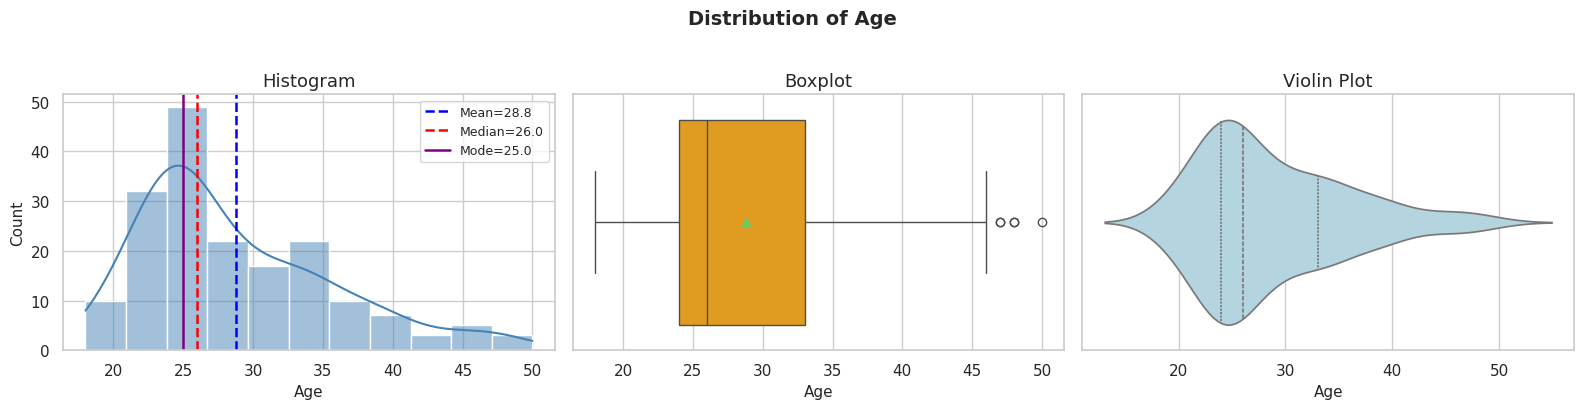

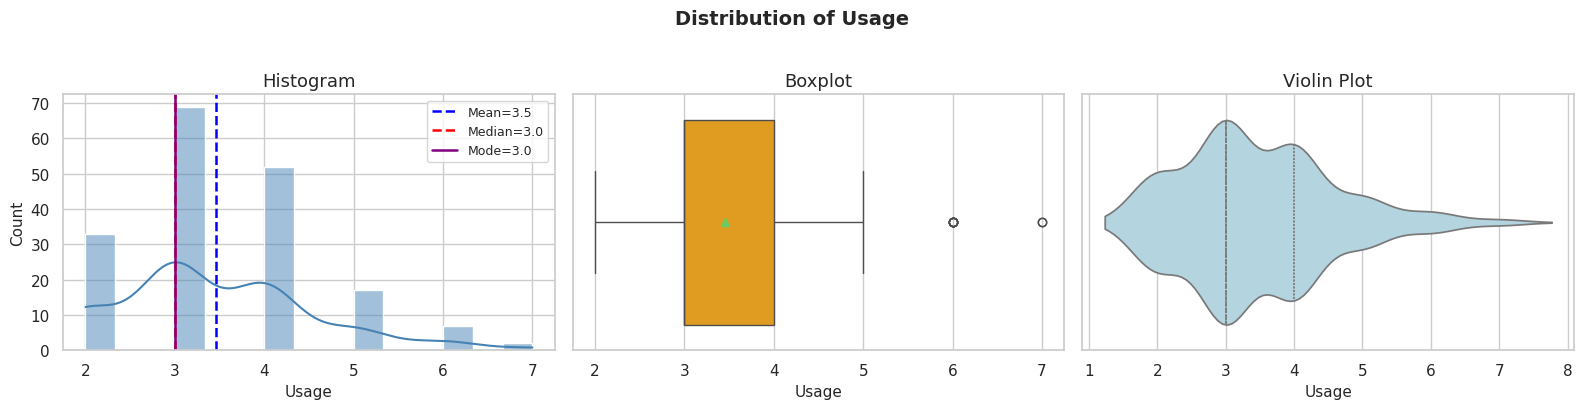

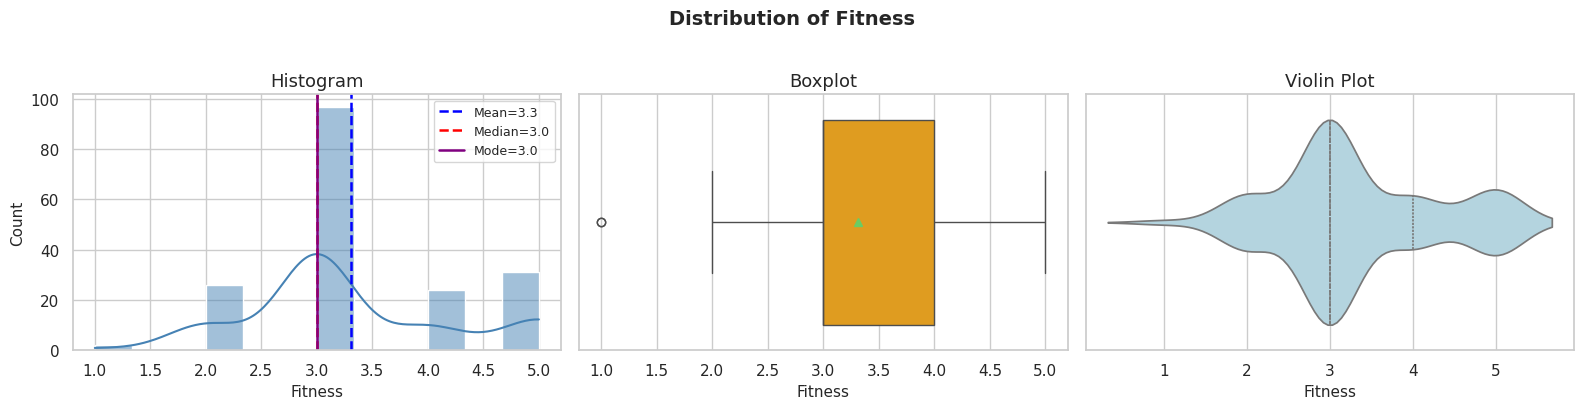

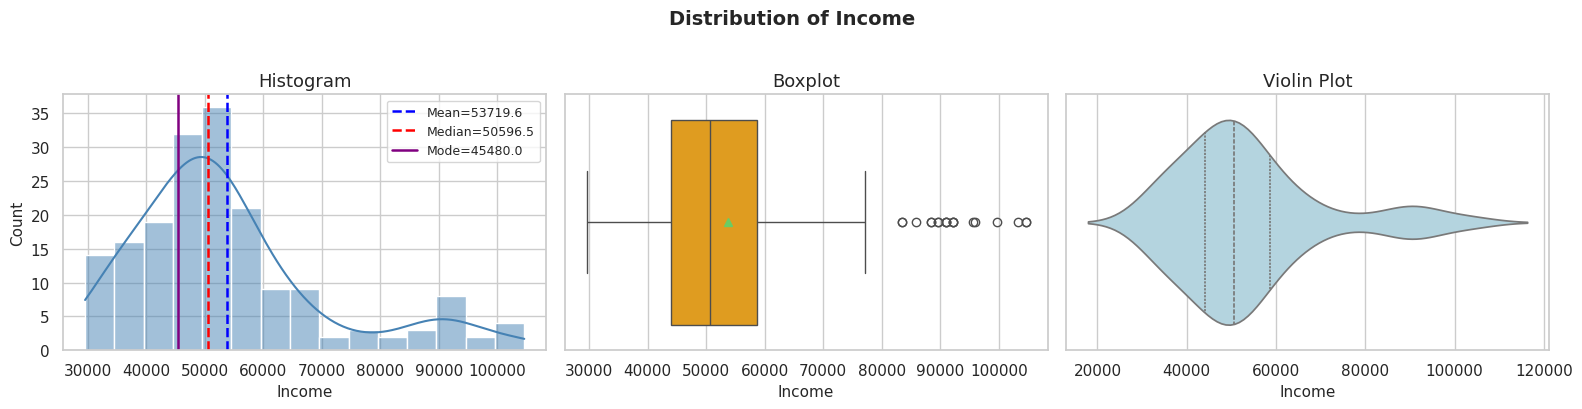

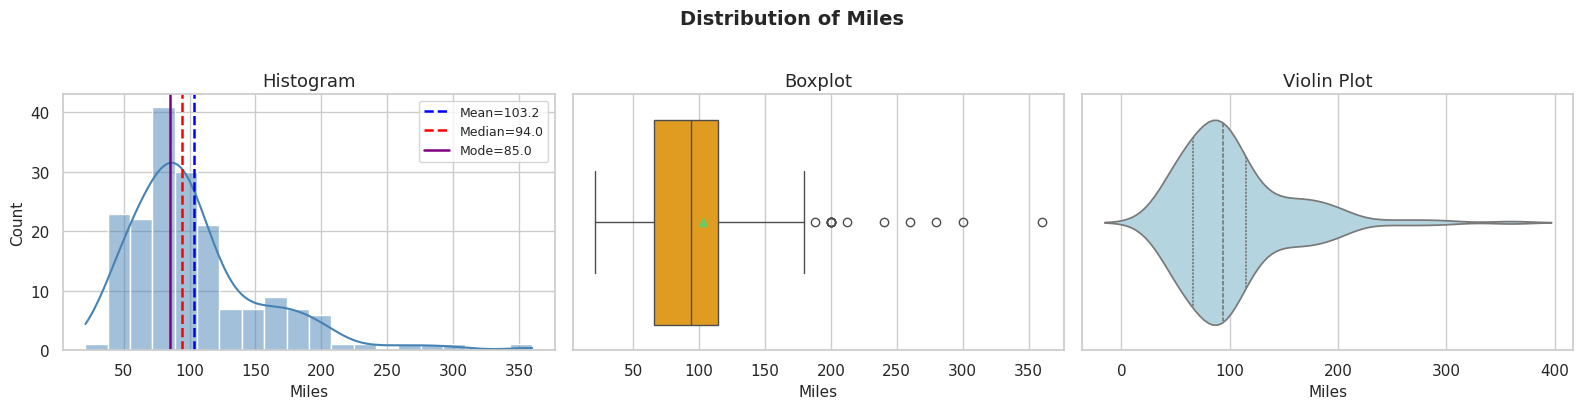

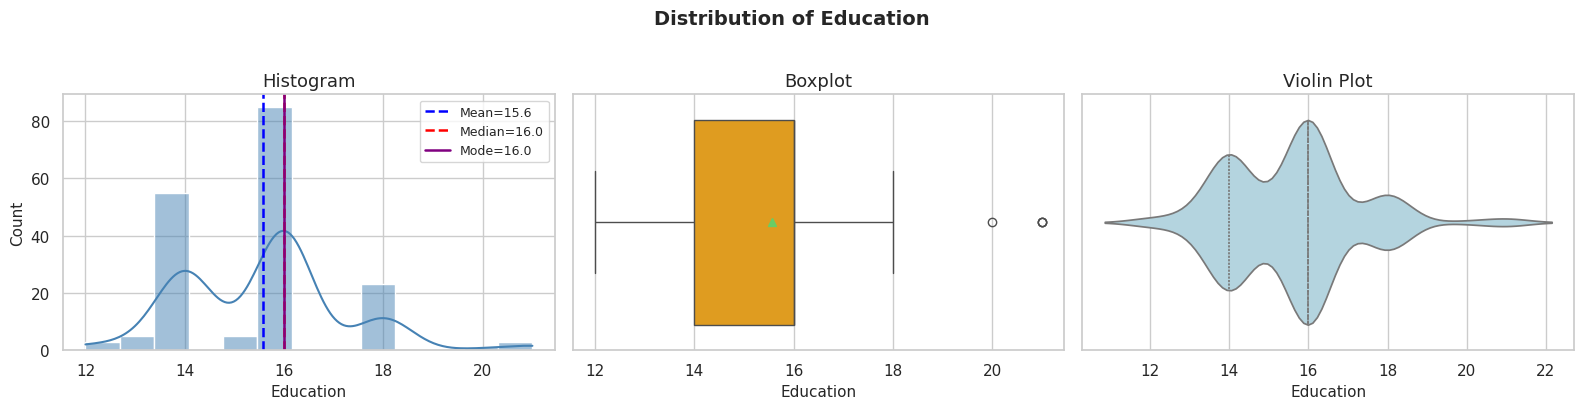

In [7]:
def plot_distribution(series, color_hist='steelblue', color_box='orange'):
    """Three-panel distribution diagnostic for a numerical series."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Distribution of {series.name}', fontsize=14, fontweight='bold', y=1.02)

    # Histogram
    sns.histplot(series, kde=True, color=color_hist, ax=axes[0])
    axes[0].axvline(series.mean(),   color='blue',   linestyle='--', linewidth=1.8, label=f'Mean={series.mean():.1f}')
    axes[0].axvline(series.median(), color='red',    linestyle='--', linewidth=1.8, label=f'Median={series.median():.1f}')
    axes[0].axvline(series.mode()[0],color='purple', linestyle='-',  linewidth=1.8, label=f'Mode={series.mode()[0]:.1f}')
    axes[0].legend(fontsize=9)
    axes[0].set_title('Histogram')

    # Boxplot
    sns.boxplot(x=series, color=color_box, showmeans=True, orient='h', ax=axes[1])
    axes[1].set_title('Boxplot')

    # Violin
    sns.violinplot(x=series, ax=axes[2], inner='quartile', color='lightblue')
    axes[2].set_title('Violin Plot')

    plt.tight_layout()
    plt.show()

numerical_cols = ['Age', 'Usage', 'Fitness', 'Income', 'Miles', 'Education']
for col in numerical_cols:
    plot_distribution(df[col])

**Observations — Numerical Features:**
- **Age:** Right-skewed; most buyers are 24–35. A few outliers above 45 exist but aren't extreme.
- **Income:** Noticeably right-skewed with high earners (>$80K) as outliers — these are likely KP781 buyers.
- **Miles:** Right-skewed; most customers target 50–150 miles/week. Outliers (>200 miles) represent highly active users.
- **Usage:** Peaks at 3 days/week. Values of 6–7 days appear as outliers — extreme commitment.
- **Fitness:** Roughly symmetric around 3 (average self-rating). Few customers rate themselves 1 or 5.
- **Education:** Concentrated at 16 years (bachelor's degree equivalent).

> **Outlier note:** High-income and high-mileage outliers are genuine KP781 customer patterns, not data errors — they should be retained.

### 6b. Categorical Features — Count Distributions

/tmp/ipykernel_3859/1581969333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Product',       data=df, order=df['Product'].value_counts().index,       ax=axes[0], palette='Blues_d')
/tmp/ipykernel_3859/1581969333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',        data=df, order=df['Gender'].value_counts().index,        ax=axes[1], palette='Set2')
/tmp/ipykernel_3859/1581969333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='MaritalStatus', data=df, order=df['MaritalStatus'].value_counts().index, ax=ax

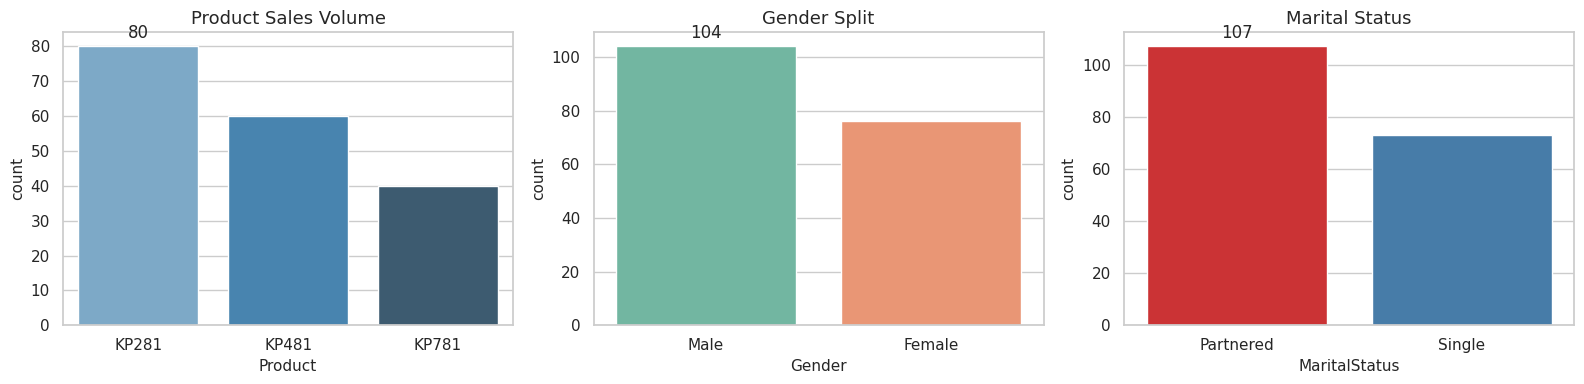


Product distribution (%):
Product
KP281    44.4
KP481    33.3
KP781    22.2

Gender distribution (%):
Gender
Male      57.8
Female    42.2

MaritalStatus distribution (%):
MaritalStatus
Partnered    59.4
Single       40.6


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x='Product',       data=df, order=df['Product'].value_counts().index,       ax=axes[0], palette='Blues_d')
sns.countplot(x='Gender',        data=df, order=df['Gender'].value_counts().index,        ax=axes[1], palette='Set2')
sns.countplot(x='MaritalStatus', data=df, order=df['MaritalStatus'].value_counts().index, ax=axes[2], palette='Set1')

for ax, title in zip(axes, ['Product Sales Volume', 'Gender Split', 'Marital Status']):
    ax.set_title(title)
    ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

# Quick percentage breakdown
for col in ['Product', 'Gender', 'MaritalStatus']:
    print(f"\n{col} distribution (%):")
    print((df[col].value_counts(normalize=True) * 100).round(1).to_string())

**Observations — Categorical Features:**
- **Product:** KP281 leads with ~44% of sales, KP481 has ~33%, and KP781 is at ~22%. The entry-level model clearly dominates.
- **Gender:** 58% Male, 42% Female — a moderate skew toward male buyers.
- **Marital Status:** 59% are partnered customers, suggesting dual-income households may drive purchasing power.

## 7. Bivariate Analysis — Product vs. Customer Characteristics

/tmp/ipykernel_3859/3162850589.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Usage', data=df, ax=axes[0,2], palette='muted')
/tmp/ipykernel_3859/3162850589.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Fitness', data=df, ax=axes[1,0], palette='coolwarm')
/tmp/ipykernel_3859/3162850589.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Income', data=df, ax=axes[1,1], palette='viridis')
/tmp/ipykernel_3859/3162850589.py:26: FutureWarning: 

Passing `palette` without assigning `hue

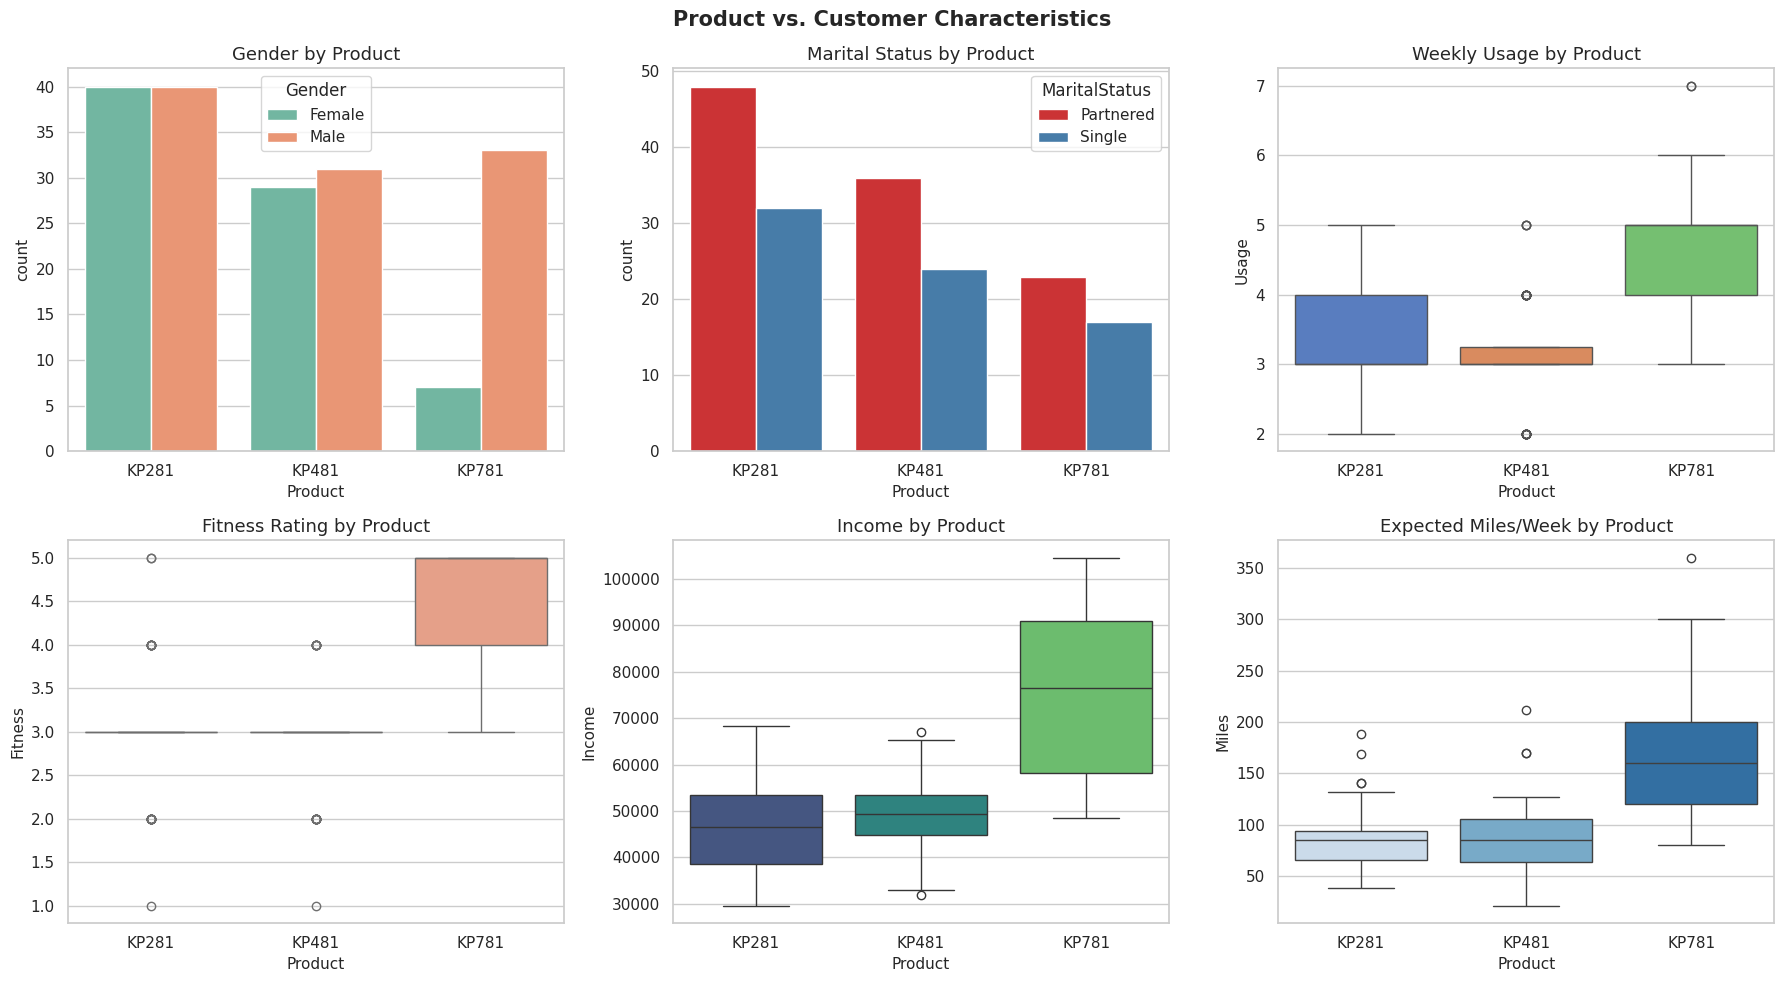

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Product vs. Customer Characteristics', fontsize=15, fontweight='bold')

# Product vs Gender
sns.countplot(x='Product', hue='Gender', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Gender by Product')
axes[0,0].legend(title='Gender')

# Product vs Marital Status
sns.countplot(x='Product', hue='MaritalStatus', data=df, ax=axes[0,1], palette='Set1')
axes[0,1].set_title('Marital Status by Product')

# Product vs Usage (boxplot)
sns.boxplot(x='Product', y='Usage', data=df, ax=axes[0,2], palette='muted')
axes[0,2].set_title('Weekly Usage by Product')

# Product vs Fitness
sns.boxplot(x='Product', y='Fitness', data=df, ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Fitness Rating by Product')

# Product vs Income
sns.boxplot(x='Product', y='Income', data=df, ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Income by Product')

# Product vs Miles
sns.boxplot(x='Product', y='Miles', data=df, ax=axes[1,2], palette='Blues')
axes[1,2].set_title('Expected Miles/Week by Product')

plt.tight_layout()
plt.show()

**Key Observations:**
- **Income separates the products clearly:** KP281/KP481 buyers cluster under $60K; KP781 buyers are typically above $75K.
- **Fitness and Miles scale with product tier:** KP781 buyers rate themselves fitter and plan to run significantly more miles.
- **Gender pattern:** KP781 is predominantly purchased by males. KP481 shows a better gender balance.
- **Usage frequency:** KP781 users plan to use the treadmill 4–5 times/week vs. 3 times for the other models.

/tmp/ipykernel_3859/2106433963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Age', data=df, palette='Set3', ax=axes[1])


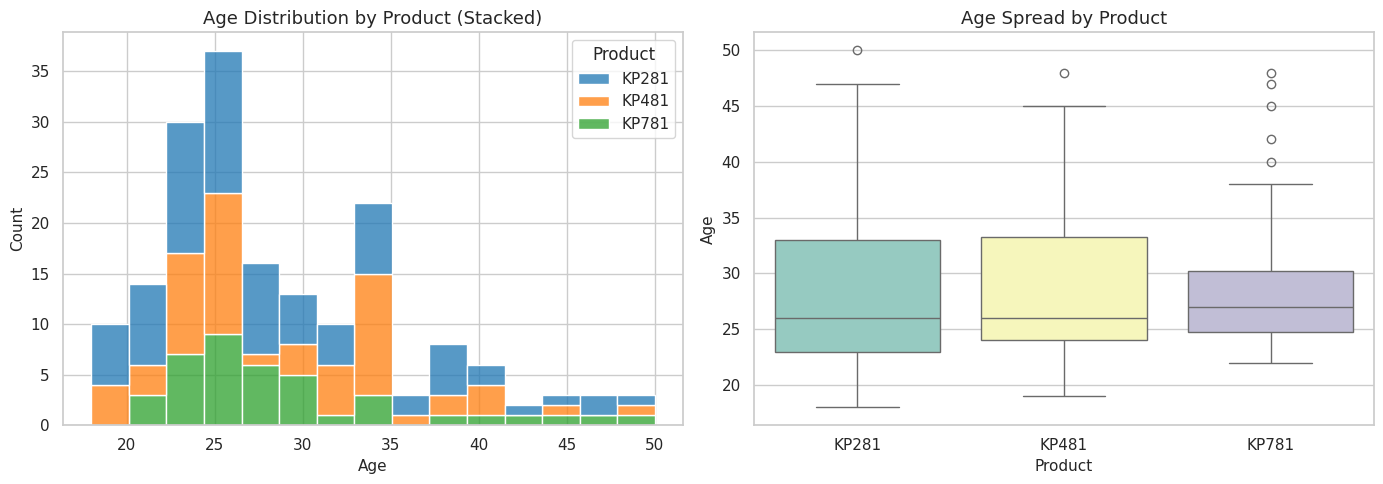

In [10]:
# Age distribution by product
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Age', hue='Product', multiple='stack', bins=15, ax=axes[0], palette='tab10')
axes[0].set_title('Age Distribution by Product (Stacked)')

sns.boxplot(x='Product', y='Age', data=df, palette='Set3', ax=axes[1])
axes[1].set_title('Age Spread by Product')

plt.tight_layout()
plt.show()

**Age Observations:**
- All three products share a similar core age range (24–35), meaning age alone is not the strongest differentiator.
- KP781 has a slightly wider spread and more buyers in the 35–45 range, suggesting experienced, higher-earning professionals.
- KP281 sees the youngest concentration of buyers.

## 8. Correlation Analysis

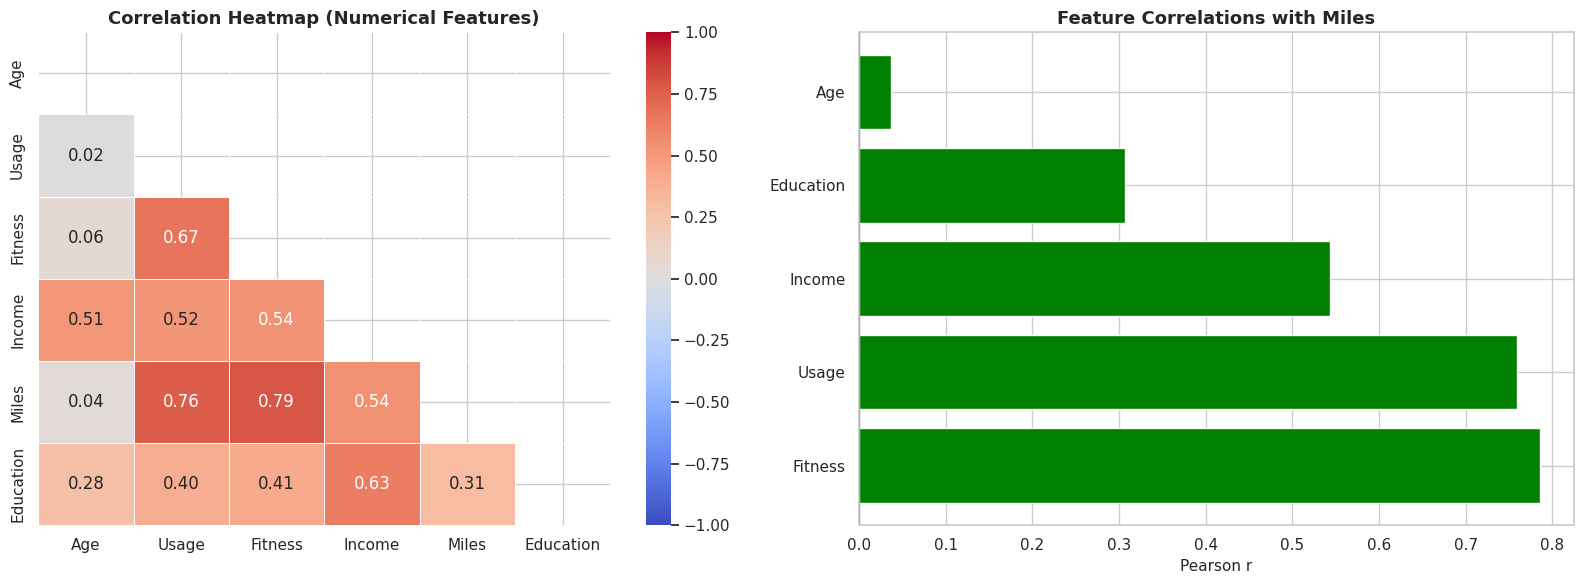

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Heatmap (Numerical Features)', fontweight='bold')

# Bar chart of strongest correlations with Miles (proxy for intensity)
corr_miles = corr['Miles'].drop('Miles').sort_values(key=abs, ascending=False)
colors = ['green' if v > 0 else 'red' for v in corr_miles]
axes[1].barh(corr_miles.index, corr_miles.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlations with Miles', fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

**Correlation Observations:**
- **Miles ↔ Fitness (r = 0.79):** The strongest relationship — fitter customers consistently plan more miles. This is intuitive and useful for recommendations.
- **Miles ↔ Usage (r = 0.76):** Customers who use the treadmill more frequently also target greater distances.
- **Income ↔ Education (r = 0.62):** Higher education correlates with higher income — both drive KP781 purchases.
- **Usage ↔ Fitness (r = 0.67):** Committed users (more days/week) tend to also consider themselves physically fit.
- **Age has low correlation with everything** — it should not be used as a primary filter for recommendations.

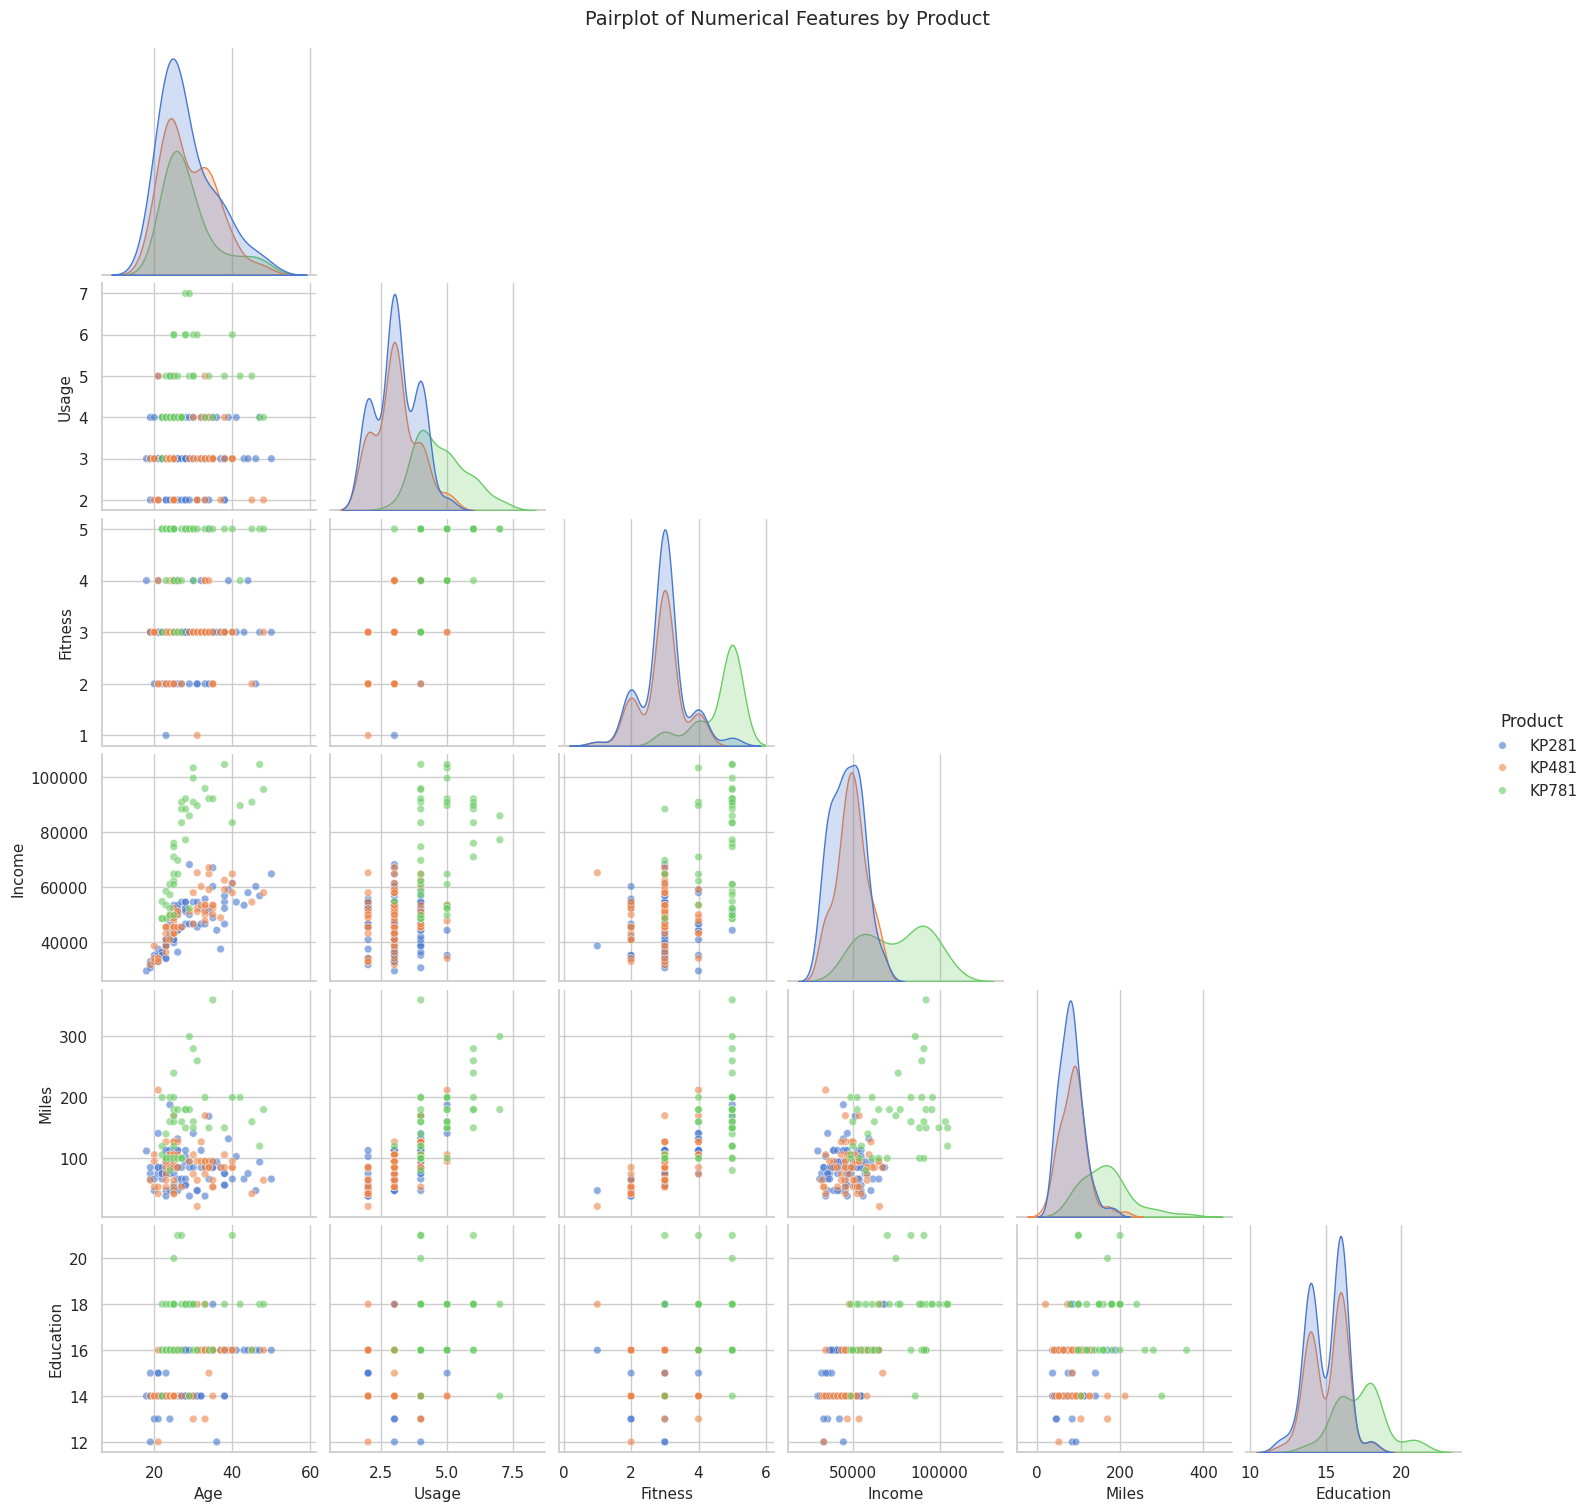

In [12]:
# Pairplot coloured by Product
sns.pairplot(df[numerical_cols + ['Product']], hue='Product', corner=True,
             plot_kws={'alpha': 0.6, 's': 30}, diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Product', y=1.01, fontsize=14)
plt.show()

## 9. Probability Analysis

### 9a. Marginal Probability — Product Market Share

Marginal probability of each product being purchased:


,P(Product)
Product,
KP281,0.444
KP481,0.333
KP781,0.222


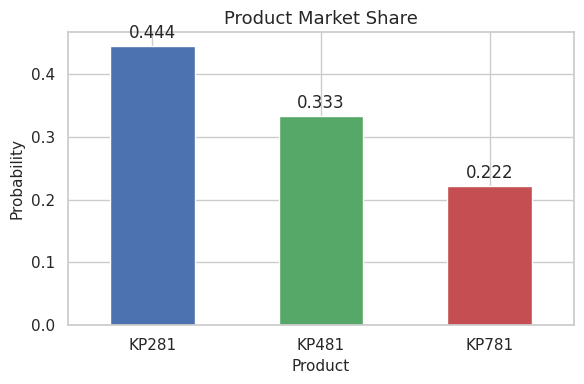

In [13]:
# Overall product market share
product_share = df['Product'].value_counts(normalize=True).rename('P(Product)').round(3)
print("Marginal probability of each product being purchased:")
display(product_share.to_frame())

ax = product_share.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'],
                        rot=0, figsize=(6, 4), title='Product Market Share')
ax.set_ylabel('Probability')
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

**Insight:** KP281 captures 44% of buyers on its own — nearly half the market. Any recommendation engine should default to KP281 for customers without a strong profile signal pointing elsewhere.

### 9b. Conditional Probability — Product by Categorical Feature

In [14]:
def crosstab_with_probability(df, row_col, col_col, bins=None, bin_labels=None):
    """
    Display a crosstab count table and its column-normalised conditional probability table.
    If bins are provided, col_col is binned before tabulating.
    """
    temp = df.copy()
    if bins is not None:
        new_col = col_col + '_Group'
        temp[new_col] = pd.cut(temp[col_col], bins=bins, labels=bin_labels)
        col_col = new_col

    ct    = pd.crosstab(temp[row_col], temp[col_col])
    cond  = ct.div(ct.sum(axis=0), axis=1).round(3)   # P(Product | group)

    print("Count Table:")
    display(ct.style.background_gradient(cmap='Greens'))
    print("\nConditional Probability  P(Product | column group):")
    display(cond.style.background_gradient(cmap='Oranges', axis=None).format("{:.3f}"))
    return ct, cond

#### Gender

In [15]:
ct_gender, cond_gender = crosstab_with_probability(df, 'Product', 'Gender')

Count Table:


Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33



Conditional Probability  P(Product | column group):


Gender,Female,Male
Product,,
KP281,0.526,0.385
KP481,0.382,0.298
KP781,0.092,0.317


**Insight:** Males have a ~55% chance of buying KP781 given their gender. Female buyers are far more evenly split between KP281 and KP481, with only ~18% opting for KP781.

#### Marital Status

In [16]:
ct_ms, cond_ms = crosstab_with_probability(df, 'Product', 'MaritalStatus')

Count Table:


MaritalStatus,Partnered,Single
Product,,
KP281,48,32
KP481,36,24
KP781,23,17



Conditional Probability  P(Product | column group):


MaritalStatus,Partnered,Single
Product,,
KP281,0.449,0.438
KP481,0.336,0.329
KP781,0.215,0.233


**Insight:** Single customers show a higher relative probability of buying KP781 than partnered customers, possibly indicating fewer financial commitments or higher personal fitness investment.

#### Income Group

In [17]:
income_bins   = [0, 40000, 60000, 80000, float('inf')]
income_labels = ['<40K', '40K–60K', '60K–80K', '>80K']
ct_inc, cond_inc = crosstab_with_probability(df, 'Product', 'Income',
                                              bins=income_bins, bin_labels=income_labels)

Count Table:


Income_Group,<40K,40K–60K,60K–80K,>80K
Product,,,,
KP281,23,51,6,0
KP481,9,44,7,0
KP781,0,11,10,19



Conditional Probability  P(Product | column group):


Income_Group,<40K,40K–60K,60K–80K,>80K
Product,,,,
KP281,0.719,0.481,0.261,0.000
KP481,0.281,0.415,0.304,0.000
KP781,0.000,0.104,0.435,1.000


**Insight:** Income is the clearest separator. Customers earning over $80K have an ~80% probability of choosing KP781. Below $60K, KP281 dominates with over 50% probability.

#### Fitness Level

In [18]:
ct_fit, cond_fit = crosstab_with_probability(df, 'Product', 'Fitness')

Count Table:


Fitness,1,2,3,4,5
Product,,,,,
KP281,1,14,54,9,2
KP481,1,12,39,8,0
KP781,0,0,4,7,29



Conditional Probability  P(Product | column group):


Fitness,1,2,3,4,5
Product,,,,,
KP281,0.500,0.538,0.557,0.375,0.065
KP481,0.500,0.462,0.402,0.333,0.000
KP781,0.000,0.000,0.041,0.292,0.935


**Insight:** Self-rated fitness of 4 or 5 strongly predicts KP781 purchase. At fitness level 1–2, KP281 is the overwhelming choice. This is one of the most actionable signals for in-store recommendations.

#### Usage Frequency

In [19]:
ct_use, cond_use = crosstab_with_probability(df, 'Product', 'Usage')

Count Table:


Usage,2,3,4,5,6,7
Product,,,,,,
KP281,19,37,22,2,0,0
KP481,14,31,12,3,0,0
KP781,0,1,18,12,7,2



Conditional Probability  P(Product | column group):


Usage,2,3,4,5,6,7
Product,,,,,,
KP281,0.576,0.536,0.423,0.118,0.000,0.000
KP481,0.424,0.449,0.231,0.176,0.000,0.000
KP781,0.000,0.014,0.346,0.706,1.000,1.000


**Insight:** Customers planning 5+ sessions/week lean heavily toward KP781. At 3 sessions/week (most common), KP281 takes ~55% of purchases.

#### Age Group

In [20]:
age_bins   = [0, 25, 35, 45, 100]
age_labels = ['<25', '25–34', '35–44', '45+']
ct_age, cond_age = crosstab_with_probability(df, 'Product', 'Age',
                                              bins=age_bins, bin_labels=age_labels)

Count Table:


Age_Group,<25,25–34,35–44,45+
Product,,,,
KP281,34,32,11,3
KP481,28,24,7,1
KP781,17,17,4,2



Conditional Probability  P(Product | column group):


Age_Group,<25,25–34,35–44,45+
Product,,,,
KP281,0.430,0.438,0.500,0.500
KP481,0.354,0.329,0.318,0.167
KP781,0.215,0.233,0.182,0.333


**Insight:** Buyers under 25 and 25–34 dominate overall volume, but the 35–44 group shows a relatively higher proportion of KP781 purchases — possibly established professionals with disposable income.

### 9c. Answering Specific Business Questions

In [21]:
# Helper: joint + conditional probabilities for any two filters
def conditional_prob(df, product, **filters):
    """P(product | all filter conditions) using Bayes' direct computation."""
    mask = pd.Series([True] * len(df), index=df.index)
    for col, val in filters.items():
        mask &= (df[col] == val)
    subset = df[mask]
    if len(subset) == 0:
        return 0.0, 0
    n_product = (subset['Product'] == product).sum()
    return round(n_product / len(subset), 3), len(subset)

# Q1: P(KP781 | Male)
p, n = conditional_prob(df, 'KP781', Gender='Male')
print(f"P(KP781 | Male)                           = {p}  (based on {n} male buyers)")

# Q2: P(KP781 | Female)
p, n = conditional_prob(df, 'KP781', Gender='Female')
print(f"P(KP781 | Female)                         = {p}  (based on {n} female buyers)")

# Q3: P(KP281 | Female, Partnered)
p, n = conditional_prob(df, 'KP281', Gender='Female', MaritalStatus='Partnered')
print(f"P(KP281 | Female, Partnered)              = {p}  (based on {n} buyers)")

# Q4: P(KP781 | Male, Single)
p, n = conditional_prob(df, 'KP781', Gender='Male', MaritalStatus='Single')
print(f"P(KP781 | Male, Single)                   = {p}  (based on {n} buyers)")

# Q5: P(KP481 | Female)
p, n = conditional_prob(df, 'KP481', Gender='Female')
print(f"P(KP481 | Female)                         = {p}  (based on {n} female buyers)")

P(KP781 | Male)                           = 0.317  (based on 104 male buyers)
P(KP781 | Female)                         = 0.092  (based on 76 female buyers)
P(KP281 | Female, Partnered)              = 0.587  (based on 46 buyers)
P(KP781 | Male, Single)                   = 0.326  (based on 43 buyers)
P(KP481 | Female)                         = 0.382  (based on 76 female buyers)


In [22]:
# Summary table of P(Product | Gender)
ct = pd.crosstab(df['Product'], df['Gender'])
prob_given_gender = ct.div(ct.sum(axis=0), axis=1).round(3)

# Marginal P(Gender)
prob_gender = df['Gender'].value_counts(normalize=True).round(3)

print("Marginal P(Gender):")
print(prob_gender.to_string())
print("\nConditional P(Product | Gender):")
display(prob_given_gender.style.background_gradient(cmap='YlOrRd', axis=None).format("{:.3f}"))

Marginal P(Gender):
Gender
Male      0.578
Female    0.422

Conditional P(Product | Gender):


Gender,Female,Male
Product,,
KP281,0.526,0.385
KP481,0.382,0.298
KP781,0.092,0.317


## 10. Customer Profiles

A summary profile for each model derived from the analysis above.

In [23]:
profile_data = {
    'Attribute'       : ['Typical Age', 'Income Range', 'Gender Skew', 'Fitness Level',
                         'Weekly Usage', 'Miles/Week', 'Marital Status'],
    'KP281 (Entry)'   : ['18–35',   '$39K–$53K',  'Balanced',       'Average (2–3)',
                         '3 days',  '50–100',      'Both; more partnered'],
    'KP481 (Mid)'     : ['24–34',   '$45K–$60K',  'Slightly Female','Average (2–3)',
                         '3 days',  '75–130',      'Both balanced'],
    'KP781 (Advanced)': ['28–45',   '$75K+',       'Strongly Male',  'High (4–5)',
                         '4–5 days','120–200+',    'More single'],
}

profile_df = pd.DataFrame(profile_data).set_index('Attribute')
display(profile_df.style.set_properties(**{'text-align': 'center'})
                        .set_table_styles([{'selector':'th','props':[('text-align','center')]}]))

,KP281 (Entry),KP481 (Mid),KP781 (Advanced)
Attribute,,,
Typical Age,18–35,24–34,28–45
Income Range,$39K–$53K,$45K–$60K,$75K+
Gender Skew,Balanced,Slightly Female,Strongly Male
Fitness Level,Average (2–3),Average (2–3),High (4–5)
Weekly Usage,3 days,3 days,4–5 days
Miles/Week,50–100,75–130,120–200+
Marital Status,Both; more partnered,Both balanced,More single


## 11. Business Insights

1. **Income and fitness rating are the two most reliable predictors of product choice.** A store associate asking "How often do you work out?" and "What's your annual budget?" can narrow down the right product in two questions.

2. **KP781 is heavily male-dominated (>80% of its buyers).** Female buyers who do purchase it tend to be high-mileage runners. There's an opportunity to increase KP781 adoption among fit, active women with targeted messaging.

3. **KP481 is the most gender-balanced product.** Marketing it as the "for everyone who's serious but not a professional" product could widen its appeal.

4. **The <$40K income segment is almost entirely KP281 territory.** Promotional pricing, EMI options, or trade-in programmes targeting this group could increase volume for the entry-level model.

5. **Customers aged 40+ are underrepresented across all products.** There is an untapped segment — health-conscious adults in their 40s and 50s — who may respond well to messaging around joint-friendly treadmill use or preventive health.

## 12. Recommendations

These are practical actions the business can take based on this analysis:

1. **Build a simple in-store recommendation guide** using two inputs — self-rated fitness (1–5) and income bracket. This alone correctly routes the majority of customers to the right model.

2. **Run a targeted campaign for KP781 aimed at active women.** Currently only ~18% of female buyers choose the KP781. Female fitness influencers or "run more, go further" messaging could close this gap.

3. **Promote KP281 and KP481 as budget-friendly, practical options** for customers earning under $60K. Avoid premium language; emphasise value and reliability.

4. **Introduce an upgrade pathway.** Customers who bought KP281 or KP481 and have been consistent users for 12+ months are natural KP781 prospects. A loyalty discount or trade-up offer could convert them.

5. **Explore the 40+ age segment.** This group is largely absent from current data. A pilot campaign around health maintenance (not athletic performance) could open a new revenue stream.

6. **Review KP781 positioning for partnered/married buyers.** Single customers currently buy KP781 at a slightly higher rate. Household-focused messaging (e.g., shared fitness goals, family wellness) could improve KP781 sales to partnered buyers.

## 13. Conclusion

- **KP281** (44% share) is the go-to product for younger, budget-conscious buyers with average fitness levels. It has the broadest appeal across gender and marital status.
- **KP481** (33% share) serves a similar demographic but attracts slightly more serious runners who want to cover more distance each week.
- **KP781** (22% share) is a niche, high-ticket product bought primarily by high-income, high-fitness male customers. Despite low volume, it likely carries strong margin contribution.

The clearest actionable signal from this analysis: **ask customers two questions — how fit they are, and what their budget is — and you can make a confident recommendation 70–80% of the time.**

---
*Analysis based on 180 customer purchases from the last 3 months. Findings should be revisited as the dataset grows.*